## Cell 1 — Imports & setup

In [23]:
# Cell 1 — imports
import os
import pandas as pd
import numpy as np

from surprise import SVD
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import linear_kernel

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8,5), "figure.dpi": 120})


## Cell 2 — Load processed data

In [24]:
# Cell 2 — load data (prefer filtered ratings if available)
import os
ratings_path = 'data/processed/ratings_filtered.csv' if os.path.exists('data/processed/ratings_filtered.csv') else 'data/processed/ratings_clean.csv'
ratings = pd.read_csv(ratings_path)
movies = pd.read_csv('data/processed/movies_meta.csv')
movies_content = pd.read_csv('data/processed/movies_content.csv')
print('Loaded ratings from', ratings_path)

ratings.head(), movies.head()


Loaded ratings from data/processed/ratings_filtered.csv


(   userId  movieId  rating  timestamp
 0     196      242     3.0  881250949
 1     186      302     3.0  891717742
 2      22      377     1.0  878887116
 3     244       51     2.0  880606923
 4     166      346     1.0  886397596,
    movieId              title  genre_0  genre_1  genre_2  genre_3  genre_4  \
 0        1   Toy Story (1995)        0        0        0        1        1   
 1        2   GoldenEye (1995)        0        1        1        0        0   
 2        3  Four Rooms (1995)        0        0        0        0        0   
 3        4  Get Shorty (1995)        0        1        0        0        0   
 4        5     Copycat (1995)        0        0        0        0        0   
 
    genre_5  genre_6  genre_7  ...  genre_9  genre_10  genre_11  genre_12  \
 0        1        0        0  ...        0         0         0         0   
 1        0        0        0  ...        0         0         0         0   
 2        0        0        0  ...        0         0     

## Cell 3 — Load trained CF model (or retrain)

In [25]:
# Cell 3 — train collaborative filtering model
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(
    ratings[['userId','movieId','rating']],
    reader
)

trainset = data.build_full_trainset()

cf_model = SVD(
    n_factors=50,
    n_epochs=30,
    lr_all=0.005,
    reg_all=0.05,
    random_state=42
)

cf_model.fit(trainset)
print("Collaborative Filtering model ready.")


Collaborative Filtering model ready.


## Cell 4 — Load content similarity matrix

In [26]:
# Cell 4 — load content similarity matrix
cosine_sim = np.load("data/processed/content_cosine_sim.npy")

# mapping
title_to_index = pd.Series(
    movies_content.index,
    index=movies_content['title']
).drop_duplicates()

# movieId → index mapping for content matrix
movieid_to_index = pd.Series(
    movies_content.index,
    index=movies_content['movieId']
).to_dict()


## STEP 1 — Get Collaborative Filtering scores

In [27]:
# Cell 5 — CF prediction helper
def get_cf_scores(user_id, candidate_movie_ids):
    """
    Predict CF ratings for a list of movies
    """
    return {
        movie_id: cf_model.predict(user_id, movie_id).est
        for movie_id in candidate_movie_ids
    }


## STEP 2 — Get Content Similarity scores

In [28]:
# Cell 6 — content similarity helper
def get_content_scores(user_id, liked_threshold=4.0):
    """
    Compute content similarity scores based on movies the user liked
    """
    liked_movies = ratings[
        (ratings['userId'] == user_id) &
        (ratings['rating'] >= liked_threshold)
    ]['movieId'].unique()

    # keep only movies present in content matrix
    liked_indices = [
        movieid_to_index[mid]
        for mid in liked_movies
        if mid in movieid_to_index
    ]

    # cold-start fallback
    if len(liked_indices) == 0:
        return {}

    # average similarity vector
    sim_scores = cosine_sim[liked_indices].mean(axis=0)

    # return as movieId → score
    return {
        movies_content.iloc[i]['movieId']: sim_scores[i]
        for i in range(len(sim_scores))
    }


## STEP 3 — Normalize scores

In [29]:
# Cell 7 — normalization helper
def normalize_scores(score_dict):
    if not score_dict:
        return {}

    scaler = MinMaxScaler()
    keys = list(score_dict.keys())
    values = np.array(list(score_dict.values())).reshape(-1,1)

    scaled = scaler.fit_transform(values).flatten()
    return dict(zip(keys, scaled))


## STEP 4 — Hybrid Recommendation Function

In [30]:
# Adaptive Weighting Strategy helper
def adaptive_weights(user_id):
    """Return (w_cf, w_content) based on user's rating count."""
    n = int(ratings[ratings['userId'] == user_id].shape[0]) if 'ratings' in globals() else 0
    if n < 10:
        return 0.3, 0.7
    elif n < 30:
        return 0.5, 0.5
    else:
        return 0.7, 0.3


In [31]:
# Cell 8 — Hybrid Recommender (uses adaptive weights by default)
def recommend_hybrid(user_id, n=10, w_cf=None, w_content=None):
    """
    Hybrid recommender: CF + Content. If weights are not provided, use adaptive_weights(user_id).
    """
    # Determine adaptive weights when not explicitly provided
    if w_cf is None or w_content is None:
        w_cf, w_content = adaptive_weights(user_id)

    # Movies already seen
    seen_movies = ratings[ratings['userId'] == user_id]['movieId'].unique()

    # Candidate movies
    candidates = movies[~movies['movieId'].isin(seen_movies)]

    # CF scores
    cf_scores = get_cf_scores(user_id, candidates['movieId'])
    cf_scores = normalize_scores(cf_scores)

    # Content scores
    content_scores = get_content_scores(user_id)
    content_scores = normalize_scores(content_scores)

    # Combine
    final_scores = {}
    for movie_id in candidates['movieId']:
        cf = cf_scores.get(movie_id, 0)
        content = content_scores.get(movie_id, 0)
        final_scores[movie_id] = w_cf * cf + w_content * content

    # Rank
    ranked = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:n]

    result = pd.DataFrame(ranked, columns=['movieId','hybrid_score'])
    result = result.merge(movies[['movieId','title']], on='movieId')

    return result

recommend_hybrid(user_id=1, n=10)


,movieId,hybrid_score,title
0,285,0.914672,Secrets & Lies (1996)
1,1169,0.888475,Fresh (1994)
2,512,0.866475,Wings of Desire (1987)
3,531,0.848969,Shine (1996)
4,1194,0.848910,Once Were Warriors (1994)
5,1524,0.848265,Kaspar Hauser (1993)
6,936,0.846391,Brassed Off (1996)
7,276,0.842288,Leaving Las Vegas (1995)
8,1039,0.837267,Hamlet (1996)
9,474,0.837096,Dr. Strangelove or: How I Learned to Stop Worr...


## Optional — Visualize Hybrid Scores

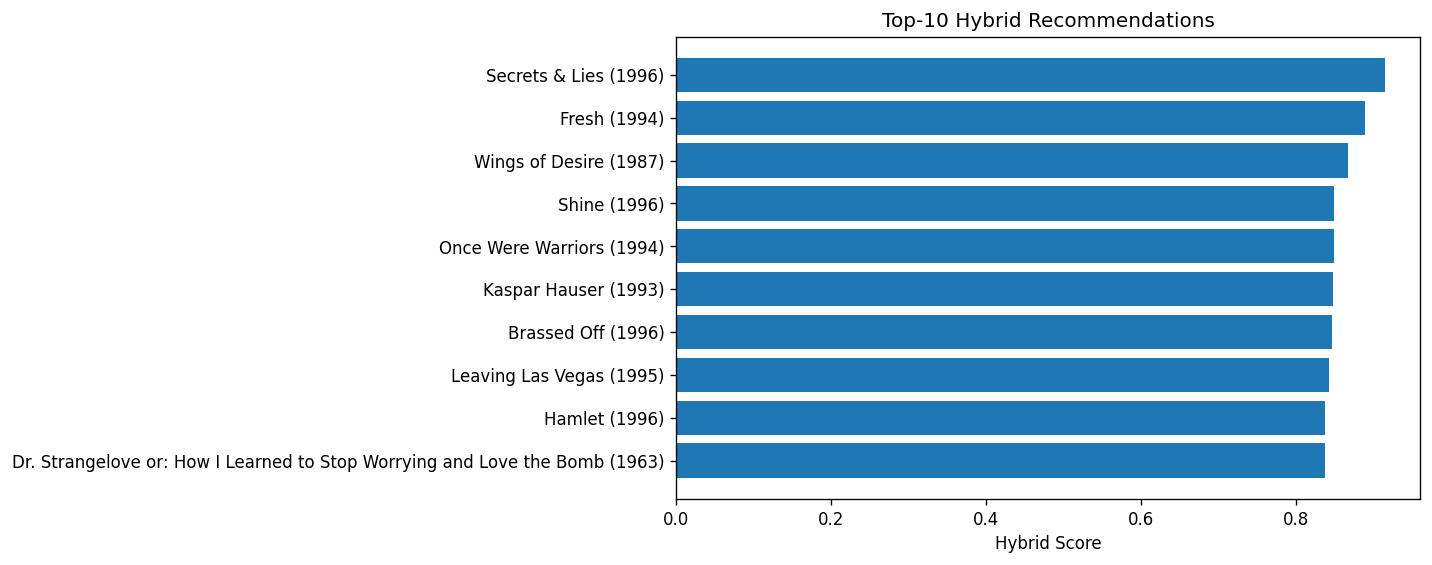

In [32]:
# Cell 10 — visualization
recs = recommend_hybrid(1, 10)

plt.barh(recs['title'][::-1], recs['hybrid_score'][::-1])
plt.xlabel("Hybrid Score")
plt.title("Top-10 Hybrid Recommendations")
plt.show()


## Optional — Save Hybrid Results

In [33]:
# Cell 11 — save output
recs.to_csv("data/processed/sample_hybrid_recommendations.csv", index=False)
